<img style="float: left; margin: 30px 15px 15px 15px;" src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="400" height="600" /> 
    
    
## <font color='navy'> Selección de Estrategias de Inversión
    
### <font color='navy'> Portafolios de Inversión

    Mtro. Sean Nicolás González Vázquez

---

### <font color='navy'> Introducción
    


En la clase pasada, aprendimos a realizar el **backtesting** de un portafolio de inversión. Como observamos, esta herramienta es fundamental tanto para evaluar como para seleccionar estrategias de inversión. Sin embargo, aún nos falta profundizar en las métricas de desempeño que complementan este análisis.

En esta clase, nuestro objetivo será extender los conocimientos adquiridos, introduciendo varias métricas financieras clave. Comenzaremos con el concepto de **Beta**, un indicador esencial en la inversión bursátil.

Además, exploraremos otras métricas de desempeño de portafolios que nos permitirán cuantificar tanto el riesgo como el rendimiento desde diferentes perspectivas. Estas métricas incluyen:


+ **Alfa de Jensen**

+ **Ratio de Treynor**

+ **Ratio de Sortino**




Durante esta clase, veremos tanto la teoría detrás de estas métricas como su aplicación práctica. Calcularemos, analizaremos e interpretaremos estos ratios para un conjunto de activos financieros, permitiéndonos tomar decisiones más informadas en la gestión de portafolios. La correcta utilización de estas herramientas mejorará nuestra capacidad de tomar decisiones financieras.

---

### <font color='navy'> Función Backtesting




Antes de calcular las métricas de desempeño, comenzaremos por **automatizar el proceso de backtesting** mediante una función en Python. El objetivo es **implementar el mismo portafolio** utilizado en la clase anterior, pero de manera **más eficiente**.

Nuestra función recibirá los **precios de cierre ajustados de los activos** que componen la cartera, la **información del cierre del benchmark**, un **diccionario con los nombres de las estrategias por simular** y sus respectivos **pesos eficientes**, además del **capital a invertir**. Como resultado, la función **devolverá el histórico de la evolución de las estrategias**, junto con su **gráfica correspondiente**.


In [1]:
# Importacion de Librerías
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
# Descarga de Datos

# Portafolio
tickers=['AAPL', 'BRK-B', 'NKE', 'LLY'] 
# Precios de optimizacion
opt_prices=yf.download(tickers, start='2021-06-20', end='2023-06-20', progress=False)['Close']

# Precios de Backtesting
bt_prices=yf.download(tickers, start='2023-06-20', end='2025-06-20', progress=False)['Close']

# Benchmark
benchmark=yf.download(['^GSPC'], start='2023-06-20', end='2025-06-20', progress=False)['Close']

# Get Optimization Returns 
opt_returns=opt_prices.pct_change().dropna()

In [3]:
# Optimización en Mínima Varianza
def opt_min_var(rets):
    
    cov=rets.cov()
    n_assets = len(rets.columns)
    
    var = lambda w: w.T @ cov @ w
    
    w0=np.ones(n_assets)/n_assets
    
    bounds=[(0, 1)]*n_assets
    
    constraint=lambda w: sum(w)-1
    
    result=minimize(fun=var, x0=w0, bounds=bounds, constraints={'fun': constraint, 'type': 'eq'}, tol=1e-16)
    
    return result.x

In [4]:
# Función para optimizar Sharpe
def opt_max_sharpe(rets, rf):
    
    E=rets.mean()
    cov=rets.cov()
    n_assets = len(rets.columns)
    
    rs = lambda w: -((w.T @ E - rf/252) / np.sqrt(w.T @ cov @ w))
    
    w0=np.ones(n_assets)/n_assets
    
    bounds=[(0, 1)]*n_assets
    
    constraint=lambda w: sum(w)-1
    
    result=minimize(fun=rs, x0=w0, bounds=bounds, constraints={'fun': constraint, 'type': 'eq'}, tol=1e-16)
    
    return result.x

In [5]:
# Función Backtesting
def static_backtesting(prices: pd.DataFrame, benchmark: pd.DataFrame, weights: dict, capital: float):
    
    # Obtener rendimientos de precios y benchmark
    rets_assets = prices.pct_change().dropna()
    rets_benchmark = benchmark.pct_change().dropna()
    
    # data frame vacio para llenar historia
    history = pd.DataFrame(index=rets_assets.index)
    
    # Obtener evolución para cada estrategia dada
    for strategy in weights.keys():

        if strategy == 'Benchmark':
            history[strategy] = (1 + rets_benchmark).cumprod() * capital

        else:
            returns_port = np.sum(rets_assets * weights.get(strategy), axis=1)
            history[strategy] = (1 + returns_port).cumprod() * capital

        
    # Graficar la evolucion para ambos portafolios
    plt.figure(figsize=(12, 6))
    plt.plot(history, label=history.columns)
    plt.legend()
    plt.xlabel('Fechas')
    plt.ylabel('Valor del Portafolio')
    plt.title('Evolución del Estrategias')
    plt.show()

    return history

In [6]:
# Optimizar pesos
rf = .04
min_var_w = opt_min_var(opt_returns)
max_sharpe_w = opt_max_sharpe(opt_returns, rf)

In [7]:
# Diccionario con estrategias por probar
strategies = {
    'Min Var': min_var_w,
    'Max Sharpe': max_sharpe_w, 
    'Benchmark' : 1 }
strategies

{'Min Var': array([6.39904986e-03, 7.38281590e-01, 2.55319361e-01, 2.16840434e-19]),
 'Max Sharpe': array([1.39452793e-01, 0.00000000e+00, 8.60547207e-01, 6.22315272e-18]),
 'Benchmark': 1}

In [8]:
# Definir capital
capital = 1_000_000

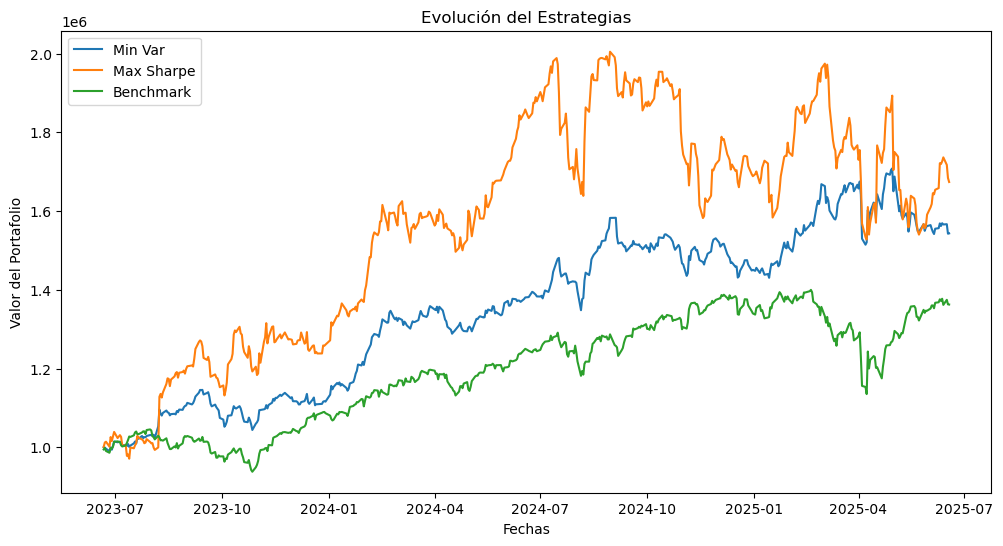

In [9]:
# Utilizar función de backtesting
history = static_backtesting(bt_prices, benchmark, strategies, capital)

In [10]:
# Mostrar history


Además, necesitamos una **función para simplificar el cálculo de las métricas de desempeño**. Esta función recibirá un **data frame con la evolución histórica de las estrategias** y la **tasa libre de riesgo**, devolviendo un **data frame con las métricas de desempeño por estrategia**.

In [11]:
# Función para las metricas de desempeño

def performance_metrics(history, rf):
    
    # Rendimiento de los portafolios
    history_rets = history.pct_change().dropna()

    # Métricas de Desempeño
    df = pd.DataFrame(columns = history.columns)

    # Rend Prom
    df.loc['Rend Prom'] = history_rets.mean() * 252
    # Volatilidad
    df.loc['Volatilidad'] = history_rets.std() * np.sqrt(252)
    # Radio de Sharpe
    df.loc['Radio de Sharpe'] = (df.loc['Rend Prom'] - rf) / df.loc['Volatilidad']
    # Downside 
    df.loc['Downside'] = (history_rets[history_rets < 0].fillna(0)).std() * np.sqrt(252)
    # Upside
    df.loc['Upside'] = (history_rets[history_rets > 0].fillna(0)).std() * np.sqrt(252)
    # Omega
    df.loc['Omega'] = df.loc['Upside'] / df.loc['Downside']
    
    return df


In [12]:
# Calcular métricas con la función
performance = performance_metrics(history, rf)
performance

,Min Var,Max Sharpe,Benchmark
Rend Prom,0.232108,0.306693,0.171634
Volatilidad,0.164106,0.309831,0.161358
Radio de Sharpe,1.170639,0.860769,0.815791
Downside,0.097820,0.179066,0.098262
Upside,0.103248,0.204992,0.103022
Omega,1.055485,1.144783,1.048437


---

### <font color='navy'> Beta
    
La **beta es una medida de sensibilidad de un activo (o portafolio) ante fluctuaciones de mercado**. Es un indicador clave del riesgo sistemático, es decir, el riesgo que no se puede diversificar. Se calcula de la siguiente manera:

$$\beta = \frac{cov(Activo, Mercado)}{var(Mercado)}$$

$$\beta = \frac{\sigma_{i, M}}{\sigma^2_M}$$

Donde:
    
+ $\sigma_{i, M}$: Covarianza del activo (o portafolio) con el mercado.
    
+ $\sigma^2_M$: Varianza del mercado.
    
La interpretación de la Beta depende de su valor, existen tres casos específicos:

| **Valor de Beta** | **Interpretación**                                                                 |
|------------------|-------------------------------------------------------------------------------------|
| **Beta > 1**     | Activo o portafolio agresivo. Mayor impacto de los movimientos del mercado. |
| **Beta = 1**     | El activo se mueve en línea con el mercado.                                          |
| **Beta < 1**     | Activo o portafolio defensivo. Menor impacto de los movimientos del mercado. |



In [24]:
rets_strategies = history.pct_change().dropna()
# Obtener covarianzas de estrategias con el mercado
cov = rets_strategies.cov()

cov ['Benchmark']

Min Var       0.000063
Max Sharpe    0.000084
Benchmark     0.000103
Name: Benchmark, dtype: float64

In [25]:
# Obtener varianza del Mercado
var_market = cov.loc['Benchmark', 'Benchmark']
var_market

0.00010331926426694569

In [26]:
# Obtener betas 
Betas = cov.loc[:, 'Benchmark'] / var_market
Betas

Min Var       0.614164
Max Sharpe    0.810254
Benchmark     1.000000
Name: Benchmark, dtype: float64

---

### <font color='navy'> Alfa de Jensen

El Alfa de Jensen mide el **rendimiento de un portafolio en relación con su rendimiento esperado ajustado por riesgo sistématico**. Indica si el portafolio ha tenido un rendimiento superior o inferior al esperado.


$$\alpha_J = R_p - [ R_f + \beta \cdot (R_m - R_f)] $$

Donde:
- $R_p$: Rendimiento del portafolio
- $R_f$: Tasa libre de riesgo
- $\beta$: Beta del portafolio en relación con el mercado
- $R_m$: Rendimiento del mercado

El Alfa de Jensen es una herramienta clave para evaluar el desempeño de un portafolio o gestor, mostrando si se están generando rendimientos por encima de lo que se esperaría de un gestor de portafolios en función del riesgo sistemático.


En términos simples **indica que tan bueno es un gestor para generar rendimientos por encima a los esperados**. Se expresa en porcentaje.

In [29]:
# Obtener rendimientos para todos los portafolios (estrategias)
R_p = rets_strategies.mean() * 252
R_p

Min Var       0.232108
Max Sharpe    0.306693
Benchmark     0.171634
dtype: float64

In [30]:
# Definir tasa libre de riesgo
rf

0.04

In [31]:
# Obtener rendimiento de mercado
R_m = R_p['Benchmark']
R_m

0.17163448028329256

In [33]:
# Obtener alfa de jensen
E_R = rf + Betas * (R_m - rf)
#### R_m - rf ----> Equity Risk Premium, Rend de mercado en exceso a la tasa libre de riesgo

alfa_jensen = R_p - E_R
alfa_jensen

Min Var       0.111263
Max Sharpe    0.160035
Benchmark     0.000000
dtype: float64

---

### <font color='navy'> Ratio de Treynor
    
El Ratio de Treynor es una métrica que mide el **rendimiento ajustado por riesgo sistemático** (Beta) de un portafolio. A diferencia del ratio de Sharpe, que ajusta el rendimiento en función de la volatilidad total, el ratio de Treynor solo toma en cuenta el riesgo que proviene del mercado, es decir, el riesgo no diversificable. Mide las unidades de rendimiento generadas por unidad de riesgo sistemático asumido.


$$T = \frac{R_p - R_f}{\beta}$$

Donde:
    
- $R_p$: Rendimiento del portafolio
- $R_f$: Tasa libre de riesgo
- $\beta$: Beta del portafolio



El ratio de Treynor es útil para comparar portafolios con diferentes niveles de exposición al riesgo sistemático. Un ratio más alto indica un mejor desempeño ajustado por el riesgo de mercado.

In [34]:
# Obtener Ratio de Treynor
Treynor = (R_p - rf) / Betas
Treynor

Min Var       0.312797
Max Sharpe    0.329147
Benchmark     0.131634
dtype: float64

---

### <font color='navy'> Ratio de Sortino
    
    
El Ratio de Sortino es una variación del ratio de Sharpe que ajusta el **rendimiento de un portafolio en función de su riesgo a la baja** (downside risk), es decir, solo tiene en cuenta la volatilidad de los rendimientos que están por debajo de un cierto umbral o rendimiento objetivo. Mide las unidades de rendimiento generadas por unidad de downside risk asumida.

$$S = \frac{R_p - R_f}{\sigma_d}$$

Donde:
- $R_p$:  Rendimiento del portafolio
- $R_f$:  Tasa libre de riesgo
- $\sigma_d$:  Desviación estándar de los rendimientos por debajo de un rendimiento objetivo (volatilidad negativa)

El ratio de Sortino solo penaliza el riesgo de caída del rendimiento, lo que lo hace más preciso cuando se evalúa el riesgo relacionado con las pérdidas en lugar de la volatilidad total.

In [35]:
# Obtener downside risk
downside_risk = (rets_strategies[rets_strategies < 0].fillna(0)).std() * np.sqrt(252)
downside_risk

Min Var       0.097820
Max Sharpe    0.179066
Benchmark     0.098262
dtype: float64

In [36]:
# Obtener Ratio de Sortino
Sortino = (R_p - rf) / downside_risk
Sortino

Min Var       1.963894
Max Sharpe    1.489354
Benchmark     1.339622
dtype: float64

# Ratio Tracking Error
mide cuanto rendimiento esta generando un potafolio en exceso al benchmark, que ese llama alfa o active return, entre el traking risk, que es la dispersion de este rendimiento en exceso

TE = (Rp - Rb)/ sigmaRp - Rb

Donde: 
- $R_p$: Rendimiento del portafolio 
- $R_b$: Rendimiento del benchmark

In [39]:
# Tracking Error
TE = (rets_strategies['Min Var']-rets_strategies['Benchmark']).mean()*252/(rets_strategies['Min Var']- rets_strategies['Benchmark']).std() * np.sqrt(252)
TE

105.19768693720248